## SHAP Implementation

**Data Set:** California Housing

In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
# Load the dataset
X,y = fetch_california_housing(return_X_y=True,as_frame=True)

print(f"Features: {list(X.columns)}\n")
print(f"\nTarget (Sale Price) range: {y.min():.3f} - {y.max():.3f}")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Target (Sale Price) range: 0.150 - 5.000


In [2]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

scaler=StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test=pd.DataFrame(scaler.transform(X_test), columns=X.columns)

model=GradientBoostingRegressor(n_estimators=150,max_depth=5,learning_rate=0.2, random_state=69)
model.fit(X_train, y_train)
print(f'R2 Score (Test):{model.score(X_test, y_test):.4f}')

R2 Score (Test):0.8289


In [4]:
from sklearn.metrics import r2_score

r2_score(y_test, model.predict(X_test)) # sanity check

0.8289218488720029

In [5]:
# initialize the SHAP explainer
explainer = shap.TreeExplainer(model)

# computing SHAP values for the test set
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {shap_values.shape}") # one SHAP value per feature per sample

# checking the additive property for the first prediction
base_value = explainer.expected_value

i=100 # choosing a random test sample
print(f"Base value (avg prediction): {base_value[0]:.4f}")
print(f"Actual prediction: {model.predict(X_test)[i]:.4f}")
print(f"Base + SHAP sum: {base_value[0] + shap_values[i].sum():.4f}")
print("We see that actual prediction ≈ base + SHAP sum")

SHAP values shape: (4128, 8)
Base value (avg prediction): 2.0679
Actual prediction: 2.6011
Base + SHAP sum: 2.6011
We see that actual prediction ≈ base + SHAP sum


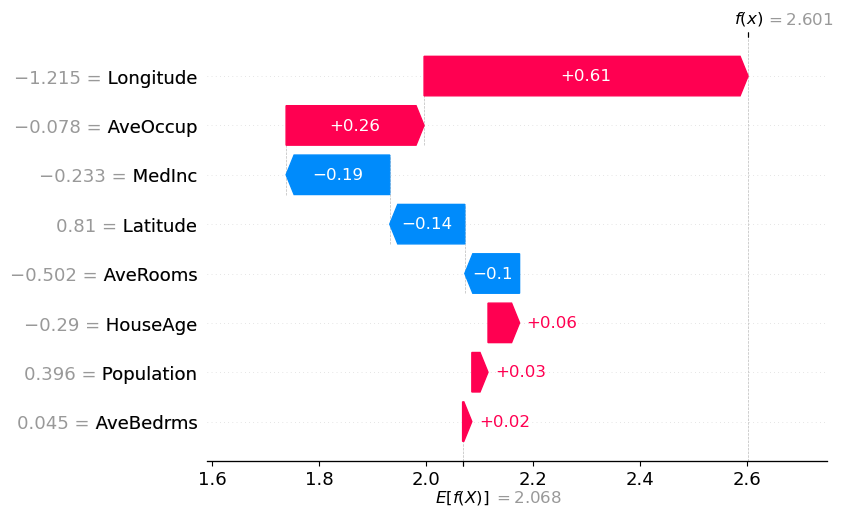

In [6]:
# explaining a random test instance
sample_idx = 100

# we use the SHAP Explanation object
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test[sample_idx],
    feature_names=X.columns.tolist()
)
shap.plots.waterfall(explanation)

In [7]:
# force plot for a single prediction
shap.initjs() # initialize JavaScript visualization
shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values[sample_idx],
    features=X_test[sample_idx],
    feature_names=X.columns.tolist()
)

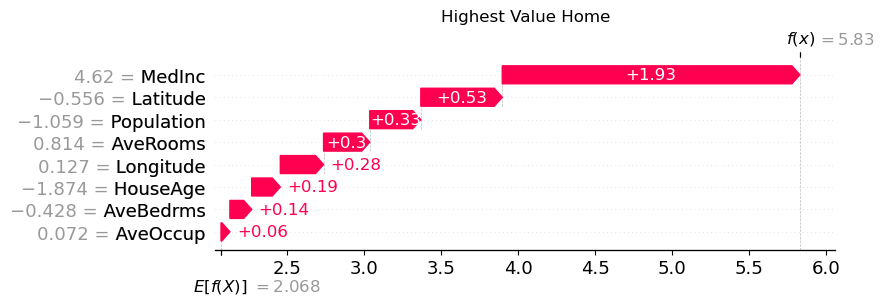

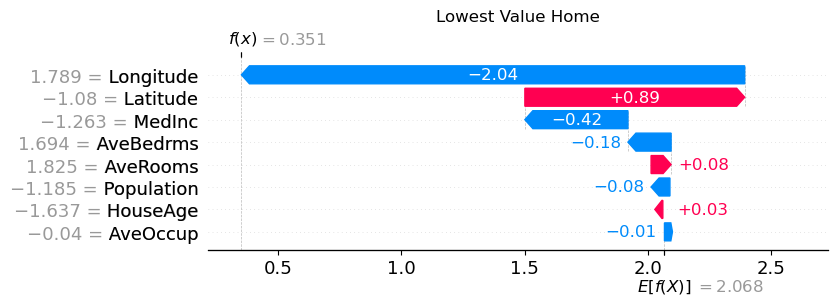

In [9]:
pred_values = model.predict(X_test)
high_idx = pred_values.argmax()
low_idx = pred_values.argmin()

plt.subplot(2,1,1)
plt.title("Highest Value Home")
shap.waterfall_plot(
        shap_values=shap.Explanation(
            values=shap_values[high_idx],
            base_values=explainer.expected_value,
            data=X_test[high_idx],
            feature_names=X.columns.tolist())
        )
plt.subplot(2,1,2)
plt.title("Lowest Value Home")

shap.waterfall_plot(
        shap_values=shap.Explanation(
            values=shap_values[low_idx],
            base_values=explainer.expected_value,
            data=X_test[low_idx],
            feature_names=X.columns.tolist())
        )
plt.show()

In [10]:
# force plot comparison: highest vs lowest predicted value
pred_values = model.predict(X_test)
high_idx = pred_values.argmax()
low_idx = pred_values.argmin()

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()[0]

for idx, label in [(high_idx, 'Highest Value Home'), (low_idx, 'Lowest Value Home')]:
    print(f"{label} | index={idx} | prediction={pred_values[idx]:.4f}")
    display(
        shap.force_plot(
            base_value=base_value,
            shap_values=shap_values[idx],
            features=X_test[idx],
            feature_names=X.columns.tolist()
            )
        )
    


Highest Value Home | index=594 | prediction=5.8303


Lowest Value Home | index=1637 | prediction=0.3509


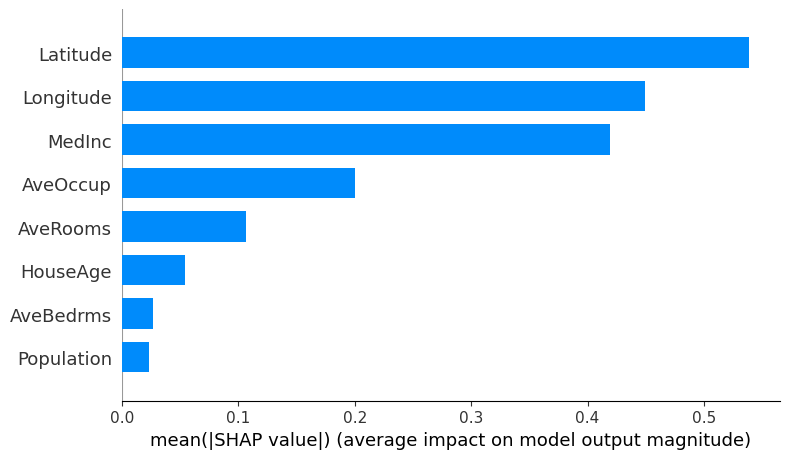

In [11]:
# Global SHAP visualization (summary): impact and direction per feature
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    plot_type='bar'
)

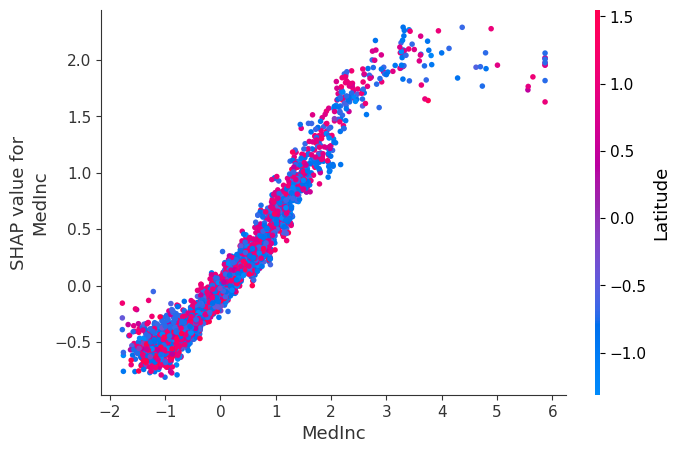

In [22]:
# Dependence plot for MedInc (one of the most important feature)
shap.dependence_plot(
    "MedInc",
    shap_values,
    X_test,
    interaction_index="Latitude"  # No coloring by interaction
)

In [23]:
# computing interaction values 
X_test_small = X_test.iloc[:500] # using a subset for speed
shap_interaction_values = explainer.shap_interaction_values(X_test_small)
print(f"Interaction values shape: {shap_interaction_values.shape}")

Interaction values shape: (500, 8, 8)


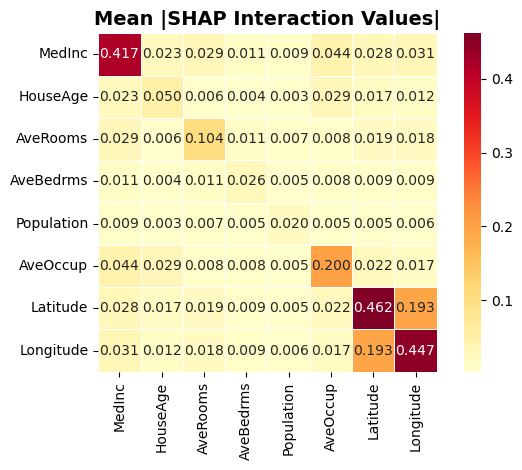

In [15]:
# average interaction matrix
mean_interactions = np.abs(shap_interaction_values).mean(axis=0)
interaction_df = pd.DataFrame(
    mean_interactions,
    index=X_test.columns,
    columns=X_test.columns
)

# plt.figure(figsize=(10, 8))
sns.heatmap(
    interaction_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    square=True,
    linewidths=0.5
)
plt.title("Mean |SHAP Interaction Values|", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

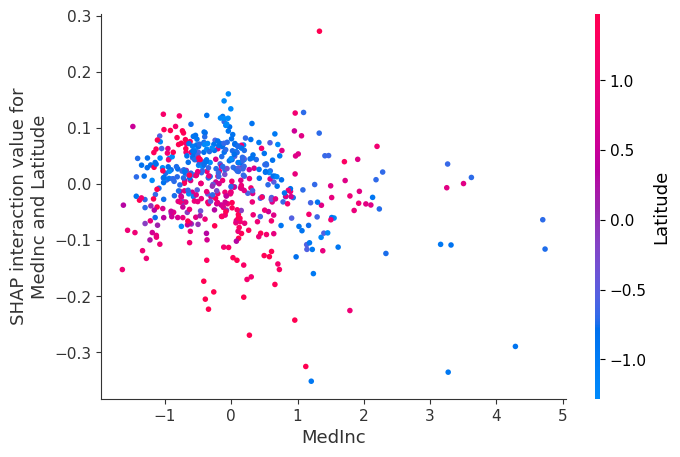

In [16]:
shap.dependence_plot(
    ("MedInc", "Latitude"),
    shap_interaction_values,
    X_test_small
)

In [24]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=69)

# splitting data by coastal vs inland (using longitude threshold)
coastal_mask = X_te['Longitude'] < -119
inland_mask = ~coastal_mask

X_coastal = X_te[coastal_mask]
X_inland = X_te[inland_mask]
shap_coastal = shap_values[coastal_mask]
shap_inland = shap_values[inland_mask]
# Compare feature importance across cohorts
coastal_importance = pd.Series(
    np.abs(shap_coastal).mean(axis=0),
    index=X.columns,
    name='Coastal'
)
inland_importance = pd.Series(
    np.abs(shap_inland).mean(axis=0),
    index=X.columns,
    name='Inland'
)
cohort_comparison = pd.DataFrame([coastal_importance, inland_importance]).T
cohort_comparison['Difference'] = cohort_comparison['Coastal'] - cohort_comparison['Inland']
print(cohort_comparison.sort_values('Difference', ascending=False).round(4))

            Coastal  Inland  Difference
Longitude    0.5108  0.3941      0.1167
Latitude     0.5997  0.4833      0.1164
MedInc       0.4213  0.4166      0.0046
AveRooms     0.1091  0.1047      0.0044
Population   0.0241  0.0234      0.0006
AveBedrms    0.0253  0.0278     -0.0025
HouseAge     0.0494  0.0585     -0.0091
AveOccup     0.1721  0.2253     -0.0532


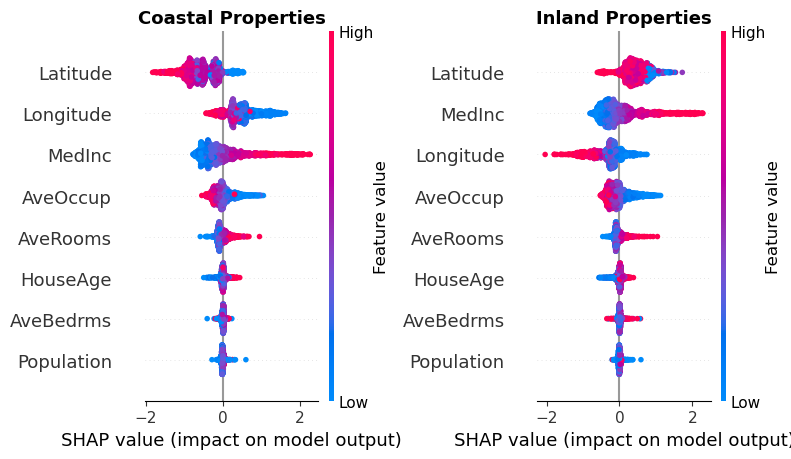

In [25]:
# visualizing with side-by-side beeswarms
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_coastal, X_coastal, show=False)
axes[0].set_title("Coastal Properties", fontsize=13, fontweight='bold')
plt.sca(axes[1])
shap.summary_plot(shap_inland, X_inland, show=False)
axes[1].set_title("Inland Properties", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# --- Model 1: Linear Model ---

linear_model = Ridge(alpha=1.0)
linear_model.fit(X_train, y_train)

linear_explainer = shap.LinearExplainer(linear_model, X_train)
linear_shap_values = linear_explainer.shap_values(X_test)

print(f"Linear Model R²: {linear_model.score(X_test, y_test):.4f}")

# --- Model 2: Random Forest ---

rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

print(f"Random Forest R²: {rf_model.score(X_test, y_test):.4f}")

# --- Model 3: Gradient Boosting (already trained) ---
print(f"GBM R²: {model.score(X_test, y_test):.4f}")

# Compare feature importances across model types
importance_comparison = pd.DataFrame({
    'Ridge (Linear)': np.abs(linear_shap_values).mean(axis=0),
    'Random Forest': np.abs(rf_shap_values).mean(axis=0),
    'Gradient Boosting': np.abs(shap_values).mean(axis=0)
}, index=X.columns)

# Normalize to compare on the same scale
importance_normalized = importance_comparison.div(importance_comparison.sum(), axis=1)
print("\nNormalized Feature Importance Comparison:")
print(importance_normalized.round(3).sort_values('Gradient Boosting', ascending=False))

Linear Model R²: 0.6060
Random Forest R²: 0.7499
GBM R²: 0.8289

Normalized Feature Importance Comparison:
            Ridge (Linear)  Random Forest  Gradient Boosting
Latitude             0.323          0.134              0.296
Longitude            0.308          0.094              0.247
MedInc               0.249          0.469              0.230
AveOccup             0.001          0.179              0.110
AveRooms             0.052          0.038              0.059
HouseAge             0.038          0.070              0.030
AveBedrms            0.029          0.010              0.015
Population           0.001          0.006              0.013


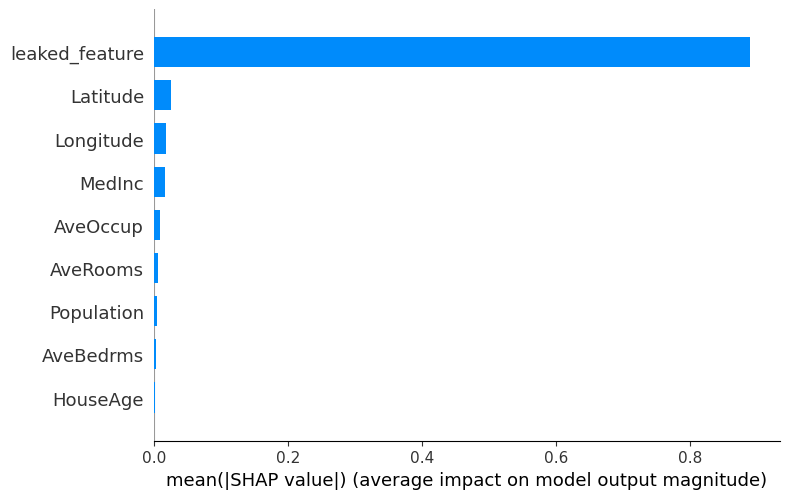

In [ ]:
# simulating a leaky feature
y_te = y_te.reset_index(drop=True)
y_tr = y_tr.reset_index(drop=True)
X_leaky = X_train.copy()
# adding a feature that partially leaks the target (simulating leakage)
rng = np.random.default_rng(seed=69)
X_leaky['leaked_feature'] = y_tr + rng.normal(0, 0.1, len(y_tr))

X_test_leaky = X_test.copy()
X_test_leaky['leaked_feature'] = y_te + rng.normal(0, 0.1, len(y_te))

# training on leaky data
leaky_model = GradientBoostingRegressor(n_estimators=150,max_depth=5,learning_rate=0.2, random_state=69)
leaky_model.fit(X_leaky, y_train)
leaky_explainer = shap.TreeExplainer(leaky_model)
leaky_shap = leaky_explainer.shap_values(X_test_leaky)
# the leaked feature will dominate SHAP importances
shap.summary_plot(leaky_shap, X_test_leaky, plot_type="bar")

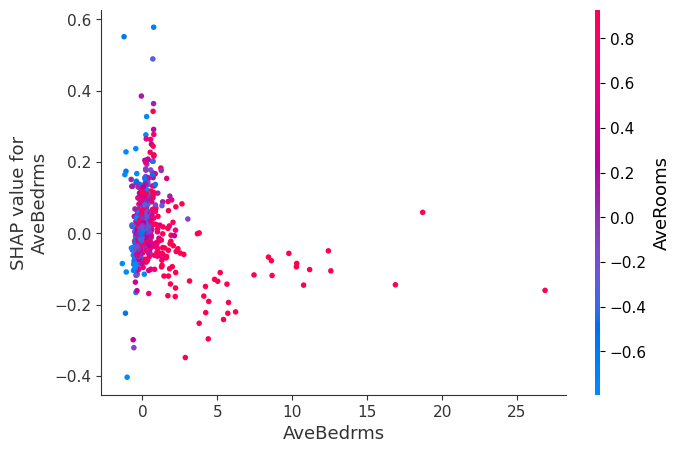

In [54]:
shap.dependence_plot("AveBedrms", shap_values, X_test)

In [59]:
# samples where the model has high magnitude SHAP values
total_shap_magnitude = np.abs(shap_values).sum(axis=1)
outlier_threshold = np.percentile(total_shap_magnitude, 95)
outlier_mask = total_shap_magnitude > outlier_threshold

print(f"Found {outlier_mask.sum()} high-impact explanations (top 5%)")
print("\nFeature statistics for outlier samples:")
display(X_te[outlier_mask].describe().round(2))

Found 207 high-impact explanations (top 5%)

Feature statistics for outlier samples:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,207.00,207.00,207.00,207.00,207.00,207.00,207.00,207.00
mean,7.23,28.98,7.26,1.19,1073.57,2.74,35.96,-120.06
std,3.69,14.87,4.20,0.95,732.94,2.75,2.75,2.71
min,0.54,2.00,2.95,0.82,5.00,1.40,32.60,-124.30
25%,4.04,18.00,5.78,1.01,562.50,2.13,33.60,-122.43
50%,7.74,28.00,7.29,1.06,907.00,2.57,34.42,-119.31
75%,9.94,40.00,8.25,1.13,1346.50,2.97,37.85,-117.64
max,15.00,52.00,62.42,14.11,4083.00,41.21,41.95,-114.49
